In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio:
[0.92461872 0.05306648]


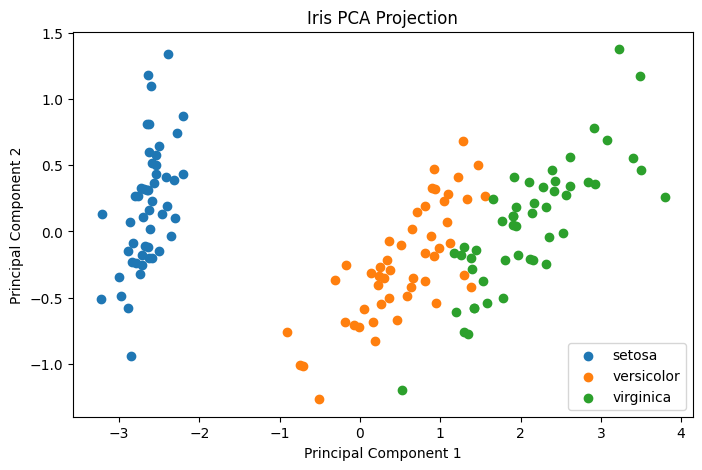

In [3]:

plt.figure(figsize=(8,5))

for species in np.unique(y):
    plt.scatter(
        X_pca[y==species,0],
        X_pca[y==species,1],
        label=iris.target_names[species]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris PCA Projection")
plt.legend()
plt.show()


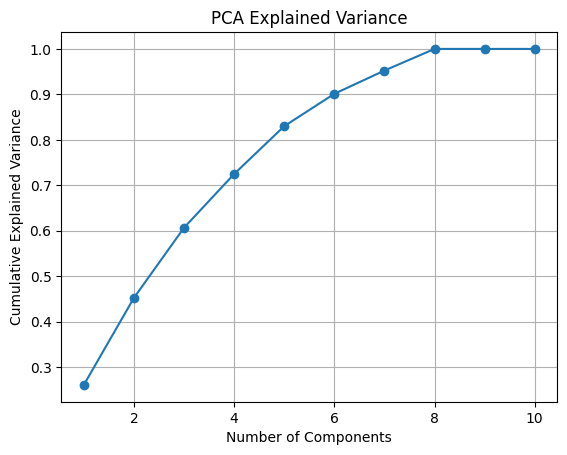

Variance explained by first 3 components:
0.6064732207303859


In [4]:
# Simulated Zomato-like dataset with 10 features

X_restaurant, _ = make_classification(
    n_samples=300,
    n_features=10,
    n_informative=8,
    random_state=42
)

X_restaurant = StandardScaler().fit_transform(X_restaurant)

pca3 = PCA(n_components=10)
pca3.fit(X_restaurant)

cum_var = np.cumsum(pca3.explained_variance_ratio_)

plt.plot(range(1,11), cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

print("Variance explained by first 3 components:")
print(cum_var[2])


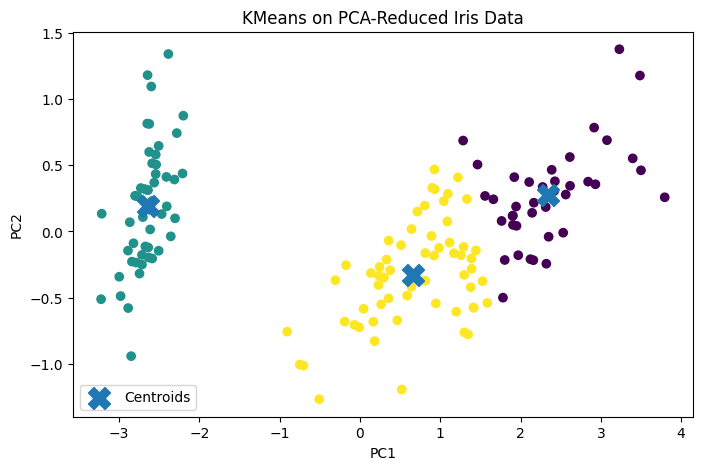

In [5]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_pca)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans on PCA-Reduced Iris Data")
plt.legend()
plt.show()


In [6]:

score = silhouette_score(X_pca, clusters)

print("Silhouette Score:", round(score,4))

print("\nInterpretation:")
print("A silhouette score closer to 1 indicates well-separated clusters.")
print("A score near 0 indicates overlapping clusters.")
print("The obtained score suggests the quality of clustering on the PCA-reduced Iris dataset.")


Silhouette Score: 0.5977

Interpretation:
A silhouette score closer to 1 indicates well-separated clusters.
A score near 0 indicates overlapping clusters.
The obtained score suggests the quality of clustering on the PCA-reduced Iris dataset.
